# Scikit-learn MPI adaptation from UL HPC Tutorial

Parallel machine learning with scikit-learn, running on a single node without Slurm

Adapted from: https://ipyparallel.readthedocs.io/en/latest/mpi.html

Check MPI:

In [1]:
! mpiexec --version

mpiexec (OpenRTE) 4.0.2

Report bugs to http://www.open-mpi.org/community/help/


Create blank Python config file to store cluster configurations:

In [2]:
%%bash
ipython profile create --parallel --profile=mpi

It only works in one terminal, open a terminal and run it, it can be a JupyterLab terminal, it will be active in the terminal, if you need to close or stop just close the terminal window:

    $ ipcluster start --profile=mpi -n 4

Ipyparallel engines running:

![](img/ul01.png)

![](img/ul02.png)

Load:

In [3]:
import ipyparallel as ipp

Start a semi-synchronous client to an IPython parallel cluster:

In [4]:
c = ipp.Client(profile='mpi')

Show the engines ready to do work:

In [50]:
c.ids

[0, 1, 2, 3]

Show the dict of all our results, keyed by msg_id (no results yet):

In [51]:
c.results

defaultdict(dict, {})

Use all engines:

In [52]:
view = c[:]

activate(targets='all', suffix='')

Create a DirectView and register it with IPython magics

Defines the magics %px, %autopx, %pxresult, %%px

e.g. rc.activate(targets=0, suffix='0') will give you the magics %px0, %pxresult0, etc. for running magics just on engine 0.


In [53]:
view.activate()

Create a file on disk:

In [54]:
%%writefile hi.py
import numpy as np
a=np.arange(16,dtype='float')

Overwriting hi.py


run(filename, targets=None, block=None)

Execute contents of filename on my engine(s)

This simply reads the contents of the file and calls execute:

In [55]:
view.run('hi.py', block=True).get()

[, , , ]

scatter(key, seq, dist='b', flatten=False, targets=None, block=None, track=None)

Partition a Python sequence and send the partitions to a set of engines.

In [56]:
with view.sync_imports():
    import numpy as np

importing numpy on engine(s)


In [57]:
view.scatter('a',np.arange(16,dtype='float')).get()

[None, None, None, None]

In [58]:
view['a']

[array([0., 1., 2., 3.]),
 array([4., 5., 6., 7.]),
 array([ 8.,  9., 10., 11.]),
 array([12., 13., 14., 15.])]

In [59]:
b = %px np.sum(a)

In [60]:
b.get()

[Out[0:6]: 6.0,
 Out[1:6]: 22.0,
 Out[2:6]: 38.0,
 Out[3:6]: 54.0]

In [61]:
b = %px tot = np.sum(a)

In [62]:
b.get()

[, , , ]

In [63]:
view['tot']

[6.0, 22.0, 38.0, 54.0]

execute(code, silent=True, targets=None, block=None)

Executes code on targets in blocking or nonblocking manner.

In [64]:
view.execute('print("oi")', block=True)

<AsyncResult: execute:finished>

In [65]:
view.results

defaultdict(dict, {})

In [2]:
import argparse
import logging
import os
import sys
# import matplotlib as mpl
# mpl.use('Agg')
# import matplotlib.pyplot as plt
# from matplotlib.colors import Normalize
from joblib import Parallel, parallel_backend
from joblib import register_parallel_backend
from joblib import delayed
from joblib import cpu_count
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from ipyparallel import Client
from ipyparallel.joblib import IPythonParallelBackend
import numpy as np
import pandas as pd
import datetime
from sklearn.model_selection import GridSearchCV

In [68]:
cpu_count()

12

In [3]:
#prepare the engines
c = Client(profile="mpi")

In [4]:
bview = c.load_balanced_view()

In [5]:
register_parallel_backend('ipyparallel',
                          lambda : IPythonParallelBackend(view=bview))

In [6]:
#Get data
digits = load_digits()

In [7]:
#prepare it for the custom function
X_train, X_test, y_train, y_test = train_test_split(digits.data,
                                                    digits.target,
                                                    test_size=0.3)

In [8]:
#some parameters to test in parallel
param_space = {
    'C': np.logspace(-6, 6, 20),
    'gamma': np.logspace(-6,1,20)
}

In [9]:
svc_rbf = SVC(kernel='rbf', shrinking=False)

In [10]:
search = GridSearchCV(svc_rbf,
                      param_space,
                      return_train_score = True,
                      n_jobs = len(c))

In [11]:
with parallel_backend('ipyparallel'):
    search.fit(X_train, y_train)

![](img/ul03.png)

In [78]:
results = search.cv_results_
results = pd.DataFrame(results)
results.to_csv('scores_rbf_digits.csv')

In [12]:
%%bash
head -3 scores_rbf_digits.csv

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.13373384475708008,0.008670249633707773,0.026911449432373048,0.0019429822036279053,1e-06,1e-06,"{'C': 1e-06, 'gamma': 1e-06}",0.10317460317460317,0.10714285714285714,0.10756972111553785,0.10756972111553785,0.10358565737051793,0.10580851198381078,0.001993125709125585,150,0.10646766169154229,0.1054726368159204,0.10536779324055666,0.10536779324055666,0.10636182902584493,0.10580754280288418,0.0004983796824442156
1,0.12189664840698242,0.004704758571591133,0.0257051944732666,0.0006720285436430215,1e-06,2.335721469090121e-06,"{'C': 1e-06, 'gamma': 2.335721469090121e-06}",0.10317460317460317,0.10714285714285714,0.10756972111553785,0.1075697211155

In [13]:
scores = search.cv_results_['mean_test_score'].reshape(len(param_space['C']),len(param_space['gamma']))

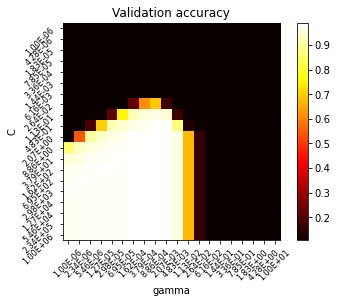

In [15]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
plt.figure()
#plt.subplots_adjust(left=.2, right=0.95, bottom=0.15, top=0.95)
plt.imshow(scores, interpolation='nearest', cmap=plt.cm.hot)
plt.xlabel('gamma')
plt.ylabel('C')
plt.colorbar()
plt.xticks(np.arange(len(param_space['gamma'])), map(lambda x : "%.2E"%(x),param_space['gamma']), fontsize=8, rotation=45)
plt.yticks(np.arange(len(param_space['C'])), map(lambda x : "%.2E"%(x),param_space['C']), fontsize=8, rotation=45)
plt.title('Validation accuracy')
plt.show()